In [11]:
from tradepy.load import import_dataset
import pandas as pd
import numpy as np

In [12]:
df_min = import_dataset('gc1', 'min')

In [13]:
df_min.info()

<class 'pandas.DataFrame'>
RangeIndex: 4565856 entries, 0 to 4565855
Data columns (total 11 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ticker      str           
 1   per         str           
 2   dtyyyymmdd  datetime64[us]
 3   time        object        
 4   open        float64       
 5   high        float64       
 6   low         float64       
 7   close       float64       
 8   volume      int64         
 9   openint     int64         
 10  datetime    datetime64[us]
dtypes: datetime64[us](2), float64(4), int64(2), object(1), str(2)
memory usage: 383.2+ MB


In [14]:
df_min.isna().sum()

ticker        0
per           0
dtyyyymmdd    0
time          0
open          0
high          0
low           0
close         0
volume        0
openint       0
datetime      0
dtype: int64

In [15]:
df_min.dtyyyymmdd.value_counts()

dtyyyymmdd
2011-08-09    1394
2011-08-11    1394
2011-08-23    1394
2011-08-24    1394
2011-08-25    1394
              ... 
2023-07-22       1
2023-08-12       1
2023-08-19       1
2023-08-26       1
2023-09-09       1
Name: count, Length: 3665, dtype: int64

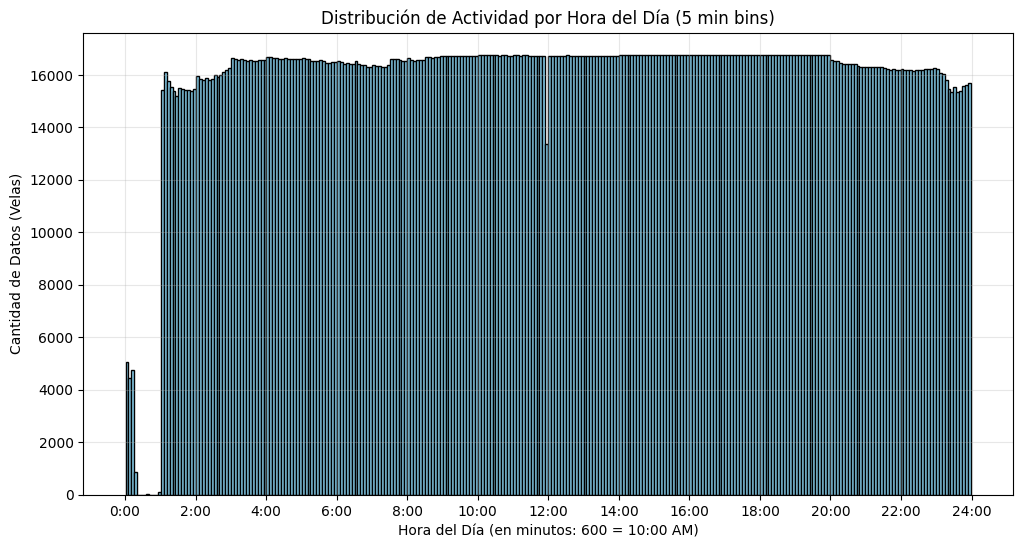

In [16]:
import matplotlib.pyplot as plt

# Convertimos el objeto time a minutos totales del día
# Asumiendo que 'datetime' ya es datetime64[us], es más fácil extraerlo de ahí:
df_min['minutes_of_day'] = df_min['datetime'].dt.hour * 60 + df_min['datetime'].dt.minute

# Graficamos el histograma
plt.figure(figsize=(12, 6))
df_min['minutes_of_day'].hist(bins=288, color='skyblue', edgecolor='black') # 288 bins = intervalos de 5 min

plt.title('Distribución de Actividad por Hora del Día (5 min bins)')
plt.xlabel('Hora del Día (en minutos: 600 = 10:00 AM)')
plt.ylabel('Cantidad de Datos (Velas)')

# Opcional: Poner los ticks en horas reales para que se entienda mejor
plt.xticks(range(0, 1441, 120), [f"{h}:00" for h in range(0, 25, 2)])
plt.grid(alpha=0.3)
plt.show()


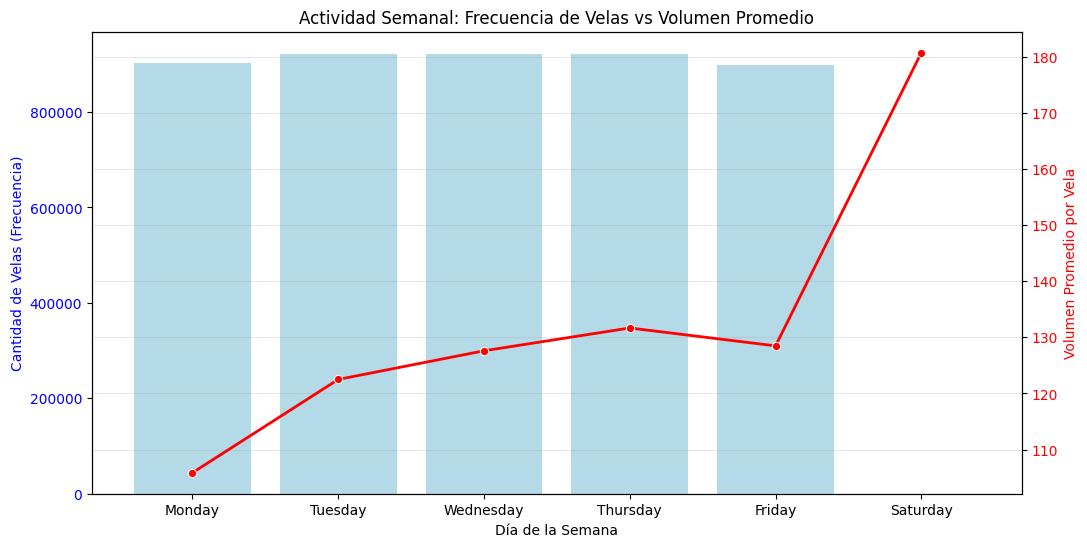

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraemos el nombre del día y el número (0=Lunes, 6=Domingo)
df_min['day_name'] = df_min['datetime'].dt.day_name()
df_min['day_of_week'] = df_min['datetime'].dt.dayofweek

# Creamos un orden lógico para los días
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Plot de conteo de velas y volumen promedio
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de Barras: Conteo de velas (Densidad de datos)
sns.countplot(data=df_min, x='day_name', order=days_order, color='skyblue', ax=ax1, alpha=0.7)
ax1.set_ylabel('Cantidad de Velas (Frecuencia)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Eje secundario para el Volumen Promedio
ax2 = ax1.twinx()
sns.lineplot(data=df_min.groupby('day_name')['volume'].mean().reindex(days_order).reset_index(), 
             x='day_name', y='volume', marker='o', color='red', ax=ax2, sort=False, linewidth=2)
ax2.set_ylabel('Volumen Promedio por Vela', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Actividad Semanal: Frecuencia de Velas vs Volumen Promedio')
ax1.set_xlabel('Día de la Semana')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [21]:
df_min.datetime.dt.day_of_week.value_counts()

datetime
3    922196
2    921818
1    921317
0    902256
4    897969
5       300
Name: count, dtype: int64